# Рубежный контроль №1 — Задача №17
## Методы обработки данных

**Студент:Чжоу Чэньюй** 

**Группа:** ИУ5И-21М

**Вариант:** 17

**Задача №17:** Нормализация числового признака с использованием преобразования Йео-Джонсона (Yeo-Johnson transformation)

**Набор данных:** California Housing (sklearn.datasets)

## 1. Импорт необходимых библиотек

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Загрузка и первичный анализ набора данных

In [16]:
# Загрузка набора данных California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print('Размер набора данных:', df.shape)
print('Первые 5 строк:')
df.head()

Размер набора данных: (20640, 9)
Первые 5 строк:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
# Информация о типах данных и пропусках
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [18]:
# Статистическое описание числовых признаков
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Выбор числового признака для нормализации

Для демонстрации преобразования Йео-Джонсона выберем признак **MedInc** (средний доход в блоке), который характеризуется выраженным правым асимметричным распределением (длинный правый хвост).

In [19]:
feature_name = 'MedInc'
feature_data = df[feature_name]

print(f'Признак: {feature_name}')
print(f'Минимум: {feature_data.min():.4f}')
print(f'Максимум: {feature_data.max():.4f}')
print(f'Среднее: {feature_data.mean():.4f}')
print(f'Медиана: {feature_data.median():.4f}')
print(f'Стандартное отклонение: {feature_data.std():.4f}')

Признак: MedInc
Минимум: 0.4999
Максимум: 15.0001
Среднее: 3.8707
Медиана: 3.5348
Стандартное отклонение: 1.8998


## 4. Анализ исходного распределения

In [20]:
# Вычисление коэффициента асимметрии (skewness)
original_skewness = stats.skew(feature_data)
print(f'Коэффициент асимметрии (skewness) до преобразования: {original_skewness:.4f}')

if original_skewness > 1:
    print('Распределение сильно скошено вправо (правый хвост)')
elif original_skewness < -1:
    print('Распределение сильно скошено влево (левый хвост)')
else:
    print('Распределение близко к симметричному')

Коэффициент асимметрии (skewness) до преобразования: 1.6465
Распределение сильно скошено вправо (правый хвост)


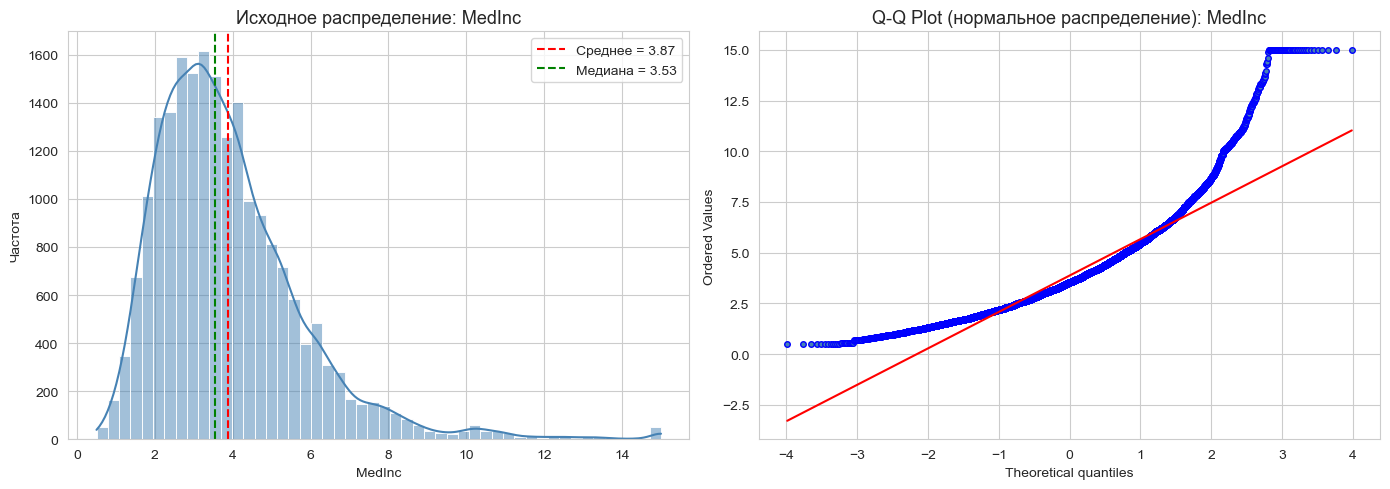

In [21]:
# Визуализация исходного распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с KDE
sns.histplot(feature_data, kde=True, bins=50, ax=axes[0], color='steelblue')
axes[0].set_title(f'Исходное распределение: {feature_name}', fontsize=13)
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Частота')
axes[0].axvline(feature_data.mean(), color='red', linestyle='--', label=f'Среднее = {feature_data.mean():.2f}')
axes[0].axvline(feature_data.median(), color='green', linestyle='--', label=f'Медиана = {feature_data.median():.2f}')
axes[0].legend()

# Q-Q plot относительно нормального распределения
stats.probplot(feature_data, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot (нормальное распределение): {feature_name}', fontsize=13)
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markersize(4)

plt.tight_layout()
plt.show()

## 5. Применение преобразования Йео-Джонсона

**Преобразование Йео-Джонсона (Yeo-Johnson)** — это обобщение преобразования Бокса-Кокса, которое поддерживает как положительные, так и отрицательные значения. Оно позволяет стабилизировать дисперсию и сделать распределение более симметричным (близким к нормальному).

Формула преобразования подбирает оптимальный параметр lambda методом максимального правдоподобия.

In [22]:
# Инициализация и применение PowerTransformer с методом 'yeo-johnson'
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# Преобразование требует 2D массив, поэтому используем reshape
feature_transformed = pt.fit_transform(feature_data.values.reshape(-1, 1)).flatten()

# Оптимальный параметр lambda
lambda_optimal = pt.lambdas_[0]
print(f'Оптимальный параметр lambda: {lambda_optimal:.4f}')

# Вычисление коэффициента асимметрии после преобразования
transformed_skewness = stats.skew(feature_transformed)
print(f'Коэффициент асимметрии (skewness) после преобразования: {transformed_skewness:.4f}')

Оптимальный параметр lambda: -0.1985
Коэффициент асимметрии (skewness) после преобразования: -0.0025


## 6. Анализ распределения после преобразования

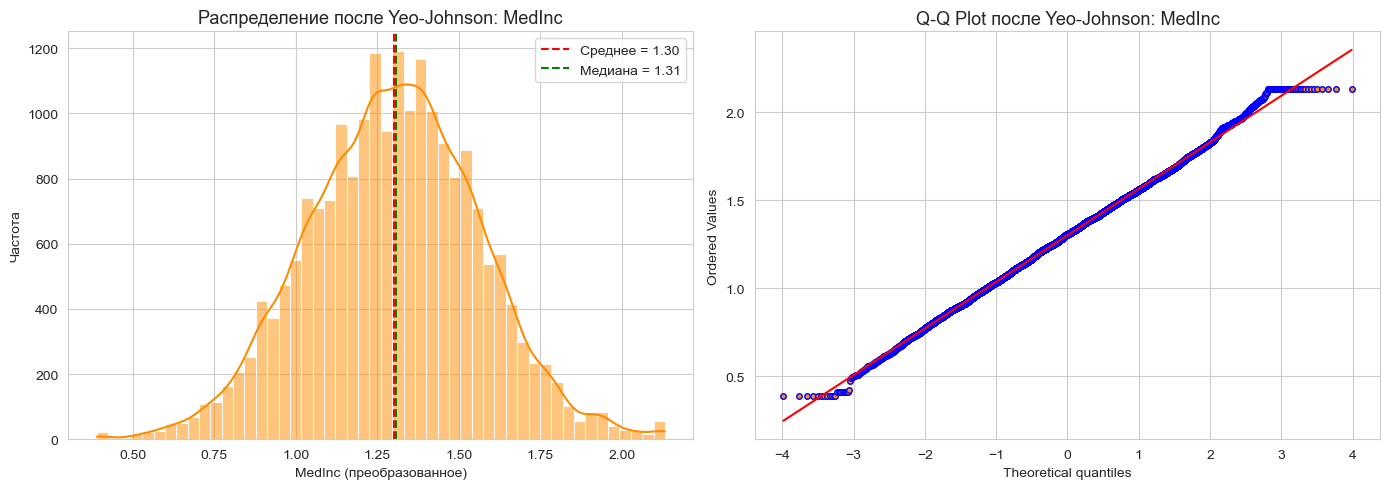

In [23]:
# Визуализация распределения после преобразования
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с KDE
sns.histplot(feature_transformed, kde=True, bins=50, ax=axes[0], color='darkorange')
axes[0].set_title(f'Распределение после Yeo-Johnson: {feature_name}', fontsize=13)
axes[0].set_xlabel(f'{feature_name} (преобразованное)')
axes[0].set_ylabel('Частота')
axes[0].axvline(np.mean(feature_transformed), color='red', linestyle='--', label=f'Среднее = {np.mean(feature_transformed):.2f}')
axes[0].axvline(np.median(feature_transformed), color='green', linestyle='--', label=f'Медиана = {np.median(feature_transformed):.2f}')
axes[0].legend()

# Q-Q plot относительно нормального распределения
stats.probplot(feature_transformed, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot после Yeo-Johnson: {feature_name}', fontsize=13)
axes[1].get_lines()[0].set_markerfacecolor('darkorange')
axes[1].get_lines()[0].set_markersize(4)

plt.tight_layout()
plt.show()

## 7. Сравнение распределений до и после преобразования

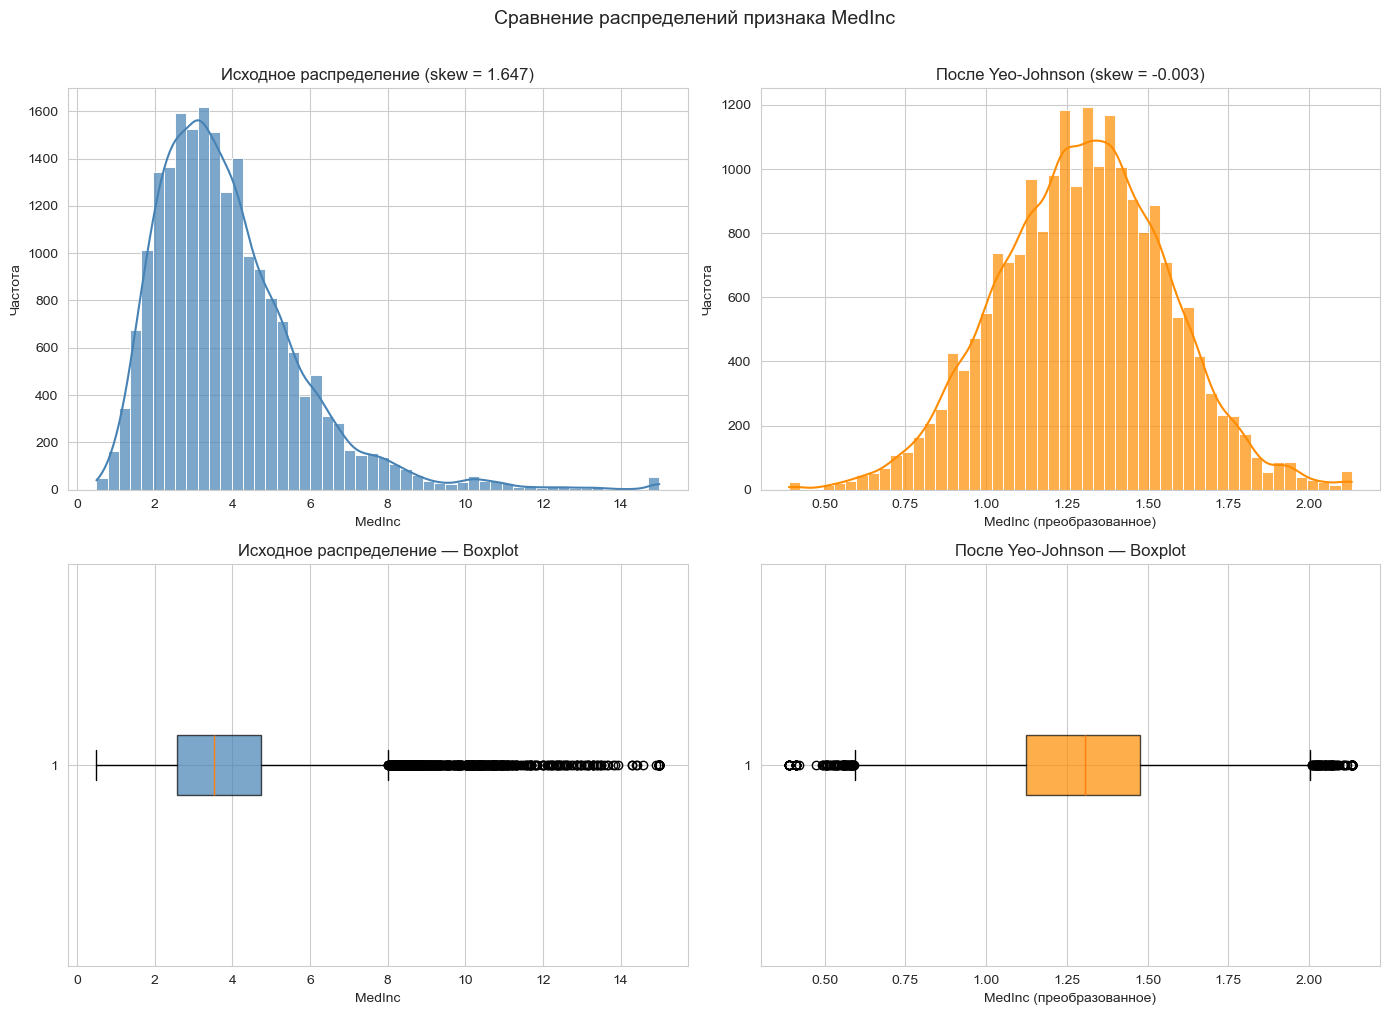

In [24]:
# Сравнительная визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Исходное распределение — гистограмма
sns.histplot(feature_data, kde=True, bins=50, ax=axes[0, 0], color='steelblue', alpha=0.7)
axes[0, 0].set_title(f'Исходное распределение (skew = {original_skewness:.3f})', fontsize=12)
axes[0, 0].set_xlabel(feature_name)
axes[0, 0].set_ylabel('Частота')

# Преобразованное распределение — гистограмма
sns.histplot(feature_transformed, kde=True, bins=50, ax=axes[0, 1], color='darkorange', alpha=0.7)
axes[0, 1].set_title(f'После Yeo-Johnson (skew = {transformed_skewness:.3f})', fontsize=12)
axes[0, 1].set_xlabel(f'{feature_name} (преобразованное)')
axes[0, 1].set_ylabel('Частота')

# Исходное распределение — boxplot
axes[1, 0].boxplot(feature_data, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1, 0].set_title('Исходное распределение — Boxplot', fontsize=12)
axes[1, 0].set_xlabel(feature_name)

# Преобразованное распределение — boxplot
axes[1, 1].boxplot(feature_transformed, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='darkorange', alpha=0.7))
axes[1, 1].set_title('После Yeo-Johnson — Boxplot', fontsize=12)
axes[1, 1].set_xlabel(f'{feature_name} (преобразованное)')

plt.suptitle(f'Сравнение распределений признака {feature_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Сводная таблица статистик
comparison_df = pd.DataFrame({
    'Метрика': ['Среднее', 'Медиана', 'Стд. отклонение', 'Минимум', 'Максимум', 'Skewness', 'Kurtosis'],
    'До преобразования': [
        feature_data.mean(),
        feature_data.median(),
        feature_data.std(),
        feature_data.min(),
        feature_data.max(),
        original_skewness,
        stats.kurtosis(feature_data)
    ],
    'После преобразования': [
        np.mean(feature_transformed),
        np.median(feature_transformed),
        np.std(feature_transformed),
        np.min(feature_transformed),
        np.max(feature_transformed),
        transformed_skewness,
        stats.kurtosis(feature_transformed)
    ]
})

comparison_df['До преобразования'] = comparison_df['До преобразования'].round(4)
comparison_df['После преобразования'] = comparison_df['После преобразования'].round(4)
comparison_df

,Метрика,До преобразования,После преобразования
0,Среднее,3.8707,1.3005
1,Медиана,3.5348,1.3060
2,Стд. отклонение,1.8998,0.2643
3,Минимум,0.4999,0.3895
4,Максимум,15.0001,2.1323
5,Skewness,1.6465,-0.0025
6,Kurtosis,4.9510,0.1013


## 8. Интерпретация результатов

**Выводы по преобразованию Йео-Джонсона для признака MedInc:**

1. **Исходное распределение** имело выраженную правую асимметрию (skewness > 1), что характерно для доходов: большинство значений сосредоточено в нижнем диапазоне, но присутствует длинный правый хвост с высокими значениями.

2. **Преобразование Йео-Джонсона** с оптимальным параметром lambda значительно уменьшило асимметрию распределения, сделав его более симметричным и близким к нормальному.

3. **Q-Q plot** после преобразования показывает, что точки лежат ближе к диагональной линии, что свидетельствует о большей близости к нормальному распределению.

4. **Преимущество Yeo-Johnson** перед Box-Cox заключается в возможности работы с любыми вещественными значениями (включая ноль и отрицательные числа), что делает его более универсальным инструментом нормализации.

## 9. Дополнительное требование — Диаграмма рассеяния (Scatter Plot)

_Требование для групп ИУ5-21М, ИУ5И-21М: построить диаграмму рассеяния для пары произвольных колонок данных._

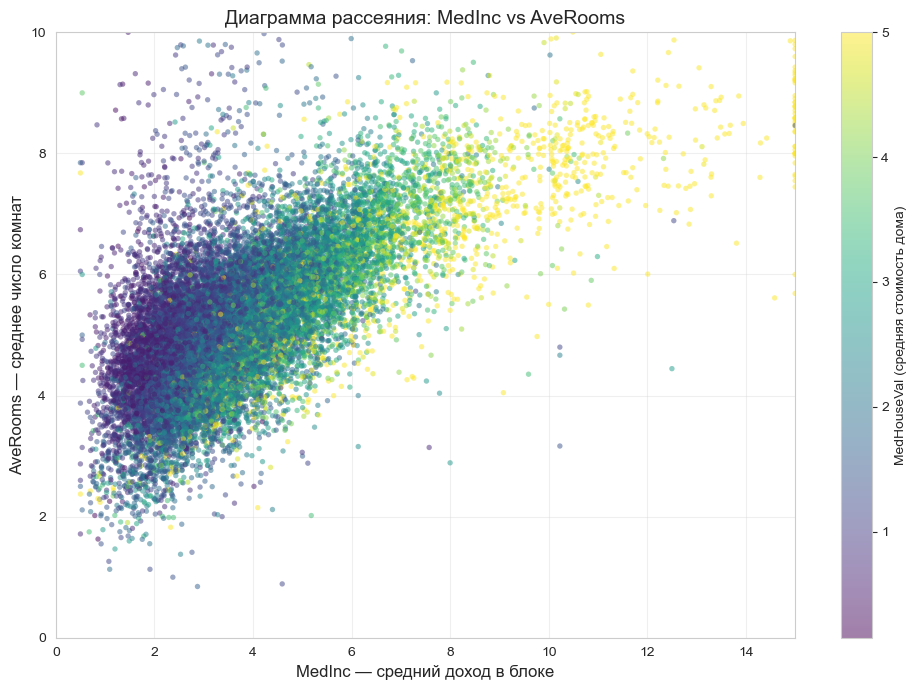

In [26]:
# Диаграмма рассеяния: MedInc vs AveRooms
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df['MedInc'],
    df['AveRooms'],
    c=df['MedHouseVal'],
    cmap='viridis',
    alpha=0.5,
    edgecolors='none',
    s=15
)

plt.colorbar(scatter, label='MedHouseVal (средняя стоимость дома)')
plt.title('Диаграмма рассеяния: MedInc vs AveRooms', fontsize=14)
plt.xlabel('MedInc — средний доход в блоке', fontsize=12)
plt.ylabel('AveRooms — среднее число комнат', fontsize=12)
plt.xlim(0, 15)
plt.ylim(0, 10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

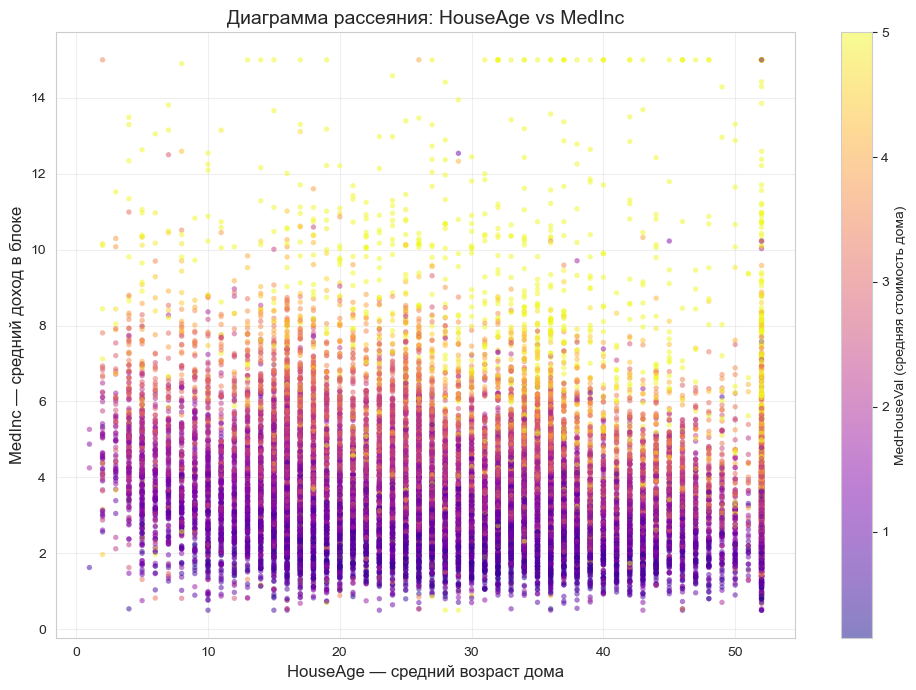

In [27]:
# Дополнительная диаграмма рассеяния: HouseAge vs MedInc
plt.figure(figsize=(10, 7))

scatter2 = plt.scatter(
    df['HouseAge'],
    df['MedInc'],
    c=df['MedHouseVal'],
    cmap='plasma',
    alpha=0.5,
    edgecolors='none',
    s=15
)

plt.colorbar(scatter2, label='MedHouseVal (средняя стоимость дома)')
plt.title('Диаграмма рассеяния: HouseAge vs MedInc', fontsize=14)
plt.xlabel('HouseAge — средний возраст дома', fontsize=12)
plt.ylabel('MedInc — средний доход в блоке', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Интерпретация диаграмм рассеяния:**

- На первой диаграмме видно, что более высокие доходы (MedInc) коррелируют с большим числом комнат (AveRooms) и более высокой стоимостью жилья (цветовая шкала).
- На второй диаграмме не наблюдается явной линейной зависимости между возрастом дома и доходом, что указывает на слабую корреляцию этих признаков.